# Exploratory Data Analysis (EDA) - Nepali News Classification

This notebook performs comprehensive exploratory data analysis on the Nepali News Dataset with 20 categories.

## Objectives:
1. Load and explore the dataset
2. Visualize category distribution
3. Analyze text length statistics
4. Show class imbalance analysis
5. Generate visualizations for proposal/report


In [3]:
# Import required libraries
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from collections import Counter

# Add src to path (notebook is in notebooks/, so go up one level to project root)
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root / 'src'))

# Ensure visualization directories exist
vis_dir = project_root / 'results' / 'visualizations'
metrics_dir = project_root / 'results' / 'metrics'

# Handle case where path exists as a file (Windows issue)
if vis_dir.exists() and vis_dir.is_file():
    vis_dir.unlink()
if metrics_dir.exists() and metrics_dir.is_file():
    metrics_dir.unlink()

# Create directories
vis_dir.mkdir(parents=True, exist_ok=True)
metrics_dir.mkdir(parents=True, exist_ok=True)

# Import custom modules
from data_loading import load_dataset_from_csv, get_dataset_statistics

# Set style for better visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

# Set random seed for reproducibility
np.random.seed(42)

print("Libraries imported successfully!")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"Matplotlib version: {plt.matplotlib.__version__}")
print(f"Seaborn version: {sns.__version__}")


Libraries imported successfully!
Pandas version: 2.2.3
NumPy version: 2.2.5
Matplotlib version: 3.10.0
Seaborn version: 0.13.2


## 1. Load and Explore Dataset


In [4]:
# Load dataset
print("Loading dataset...")
df, label_to_id, id_to_label = load_dataset_from_csv()

print(f"\n✓ Dataset loaded successfully!")
print(f"Total documents: {len(df):,}")
print(f"Number of categories: {len(label_to_id)}")
print(f"\nDataset shape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")


Loading dataset...


2026-01-04 16:42:33,902 - INFO - Loaded 6972 documents from CSV



✓ Dataset loaded successfully!
Total documents: 6,972
Number of categories: 20

Dataset shape: (6972, 4)

Columns: ['text', 'category', 'category_id', 'file_path']


In [5]:
# Display first few rows
print("First 5 rows of the dataset:")
df.head()


First 5 rows of the dataset:


,text,category,category_id,file_path
0,﻿काठमाडौंमा पहिलो पटक स्ट्रबेरीको व्यवसायिक खे...,Agriculture,0,D:\MSc Islington\NEural Networks and Deep Lear...
1,"जिल्लाका किसानले लगाएको अदुवामा गानो कुहिने, ग...",Agriculture,0,D:\MSc Islington\NEural Networks and Deep Lear...
2,काभ्रेपलाञ्चोकमा कृषकले एसआरआई प्रविधिमा गरेको...,Agriculture,0,D:\MSc Islington\NEural Networks and Deep Lear...
3,ÿþ\t\t,Agriculture,0,D:\MSc Islington\NEural Networks and Deep Lear...
4,ÿþ\t(\tM\t$\t0\tM\t0\t>\t7\tM\t \tM\t0\t?\t/\t,Agriculture,0,D:\MSc Islington\NEural Networks and Deep Lear...


In [6]:
# Basic dataset information
print("Dataset Info:")
print("=" * 60)
print(f"Total samples: {len(df):,}")
print(f"Number of categories: {df['category'].nunique()}")
print(f"Missing values: {df.isnull().sum().sum()}")
print(f"Duplicate texts: {df['text'].duplicated().sum()}")
print(f"\nData types:")
print(df.dtypes)
print(f"\nMemory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")


Dataset Info:
Total samples: 6,972
Number of categories: 20
Missing values: 3
Duplicate texts: 940

Data types:
text           object
category       object
category_id     int64
file_path      object
dtype: object

Memory usage: 27.59 MB


In [7]:
# Display all categories
print("All Categories:")
print("=" * 60)
for idx, (category, cat_id) in enumerate(sorted(label_to_id.items(), key=lambda x: x[1]), 1):
    count = len(df[df['category'] == category])
    print(f"{idx:2d}. {category:<20} (ID: {cat_id:2d}) - {count:4d} documents")


All Categories:
 1. Agriculture          (ID:  0) -  200 documents
 2. Automobiles          (ID:  1) -  246 documents
 3. Bank                 (ID:  2) -  617 documents
 4. Blog                 (ID:  3) -  259 documents
 5. Business             (ID:  4) -  306 documents
 6. Economy              (ID:  5) -  600 documents
 7. Education            (ID:  6) -  185 documents
 8. Employment           (ID:  7) -  304 documents
 9. Entertainment        (ID:  8) -  634 documents
10. Health               (ID:  9) -  180 documents
11. Interview            (ID: 10) -  330 documents
12. Literature           (ID: 11) -  251 documents
13. Migration            (ID: 12) -  111 documents
14. Opinion              (ID: 13) -  500 documents
15. Politics             (ID: 14) -  550 documents
16. Society              (ID: 15) -  353 documents
17. Sports               (ID: 16) -  650 documents
18. Technology           (ID: 17) -  118 documents
19. Tourism              (ID: 18) -  265 documents
20. World      

## 2. Visualize Category Distribution


In [8]:
# Category distribution
category_counts = df['category'].value_counts().sort_values(ascending=True)
category_percentages = (category_counts / len(df) * 100).round(2)

print("Category Distribution:")
print("=" * 60)
print(f"{'Category':<20} {'Count':<10} {'Percentage':<10}")
print("-" * 60)
for category, count in category_counts.items():
    pct = category_percentages[category]
    print(f"{category:<20} {count:<10} {pct:>6.2f}%")


Category Distribution:
Category             Count      Percentage
------------------------------------------------------------
Migration            111          1.59%
Technology           118          1.69%
Health               180          2.58%
Education            185          2.65%
Agriculture          200          2.87%
Automobiles          246          3.53%
Literature           251          3.60%
Blog                 259          3.71%
Tourism              265          3.80%
Employment           304          4.36%
Business             306          4.39%
World                313          4.49%
Interview            330          4.73%
Society              353          5.06%
Opinion              500          7.17%
Politics             550          7.89%
Economy              600          8.61%
Bank                 617          8.85%
Entertainment        634          9.09%
Sports               650          9.32%


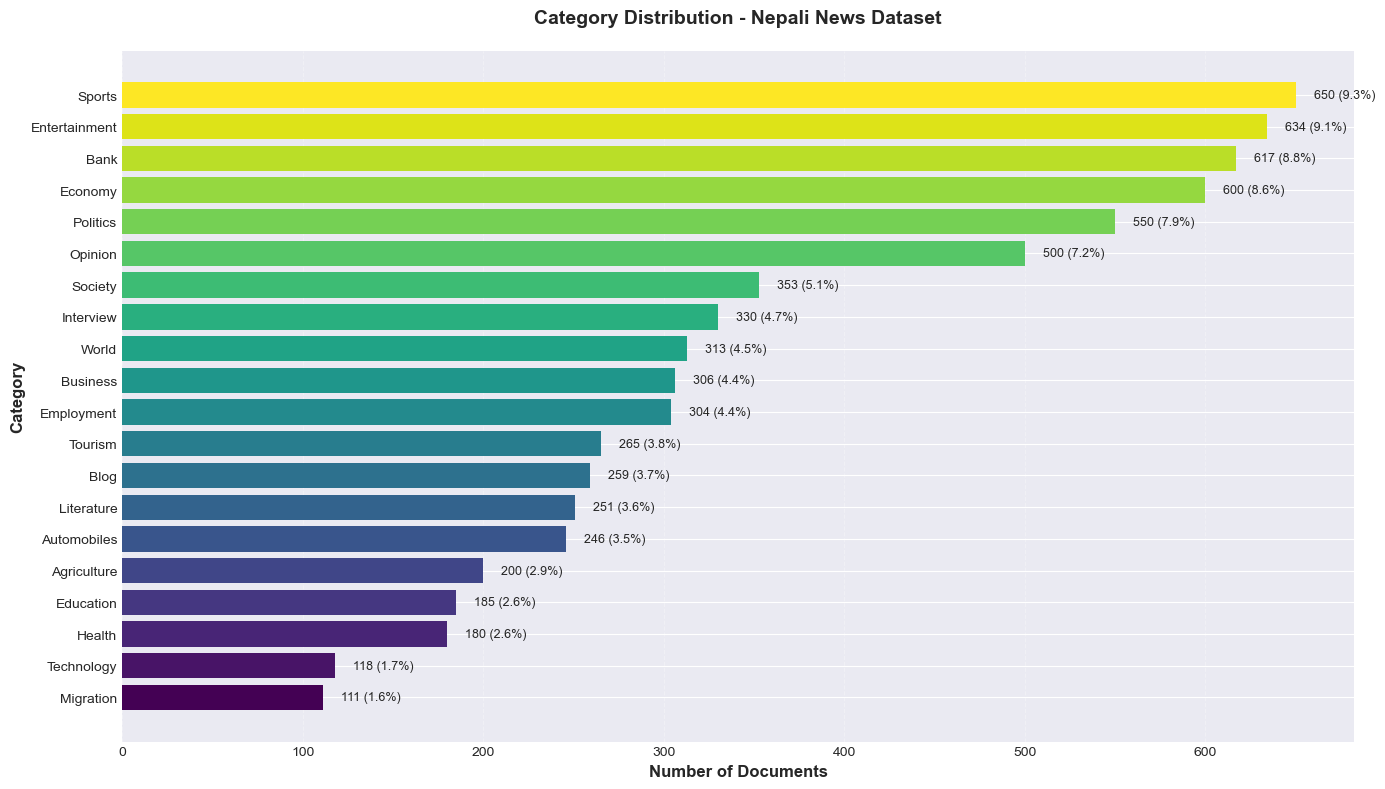

✓ Chart saved to: results/visualizations/category_distribution.png


In [9]:
# Bar chart - Category distribution
fig, ax = plt.subplots(figsize=(14, 8))
category_counts_sorted = df['category'].value_counts().sort_values(ascending=True)
colors = plt.cm.viridis(np.linspace(0, 1, len(category_counts_sorted)))

bars = ax.barh(range(len(category_counts_sorted)), category_counts_sorted.values, color=colors)
ax.set_yticks(range(len(category_counts_sorted)))
ax.set_yticklabels(category_counts_sorted.index)
ax.set_xlabel('Number of Documents', fontsize=12, fontweight='bold')
ax.set_ylabel('Category', fontsize=12, fontweight='bold')
ax.set_title('Category Distribution - Nepali News Dataset', fontsize=14, fontweight='bold', pad=20)

# Add value labels on bars
for i, (idx, val) in enumerate(zip(category_counts_sorted.index, category_counts_sorted.values)):
    ax.text(val + 10, i, f'{val} ({category_percentages[idx]:.1f}%)', 
            va='center', fontsize=9)

ax.grid(axis='x', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig(project_root / 'results' / 'visualizations' / 'category_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Chart saved to: results/visualizations/category_distribution.png")


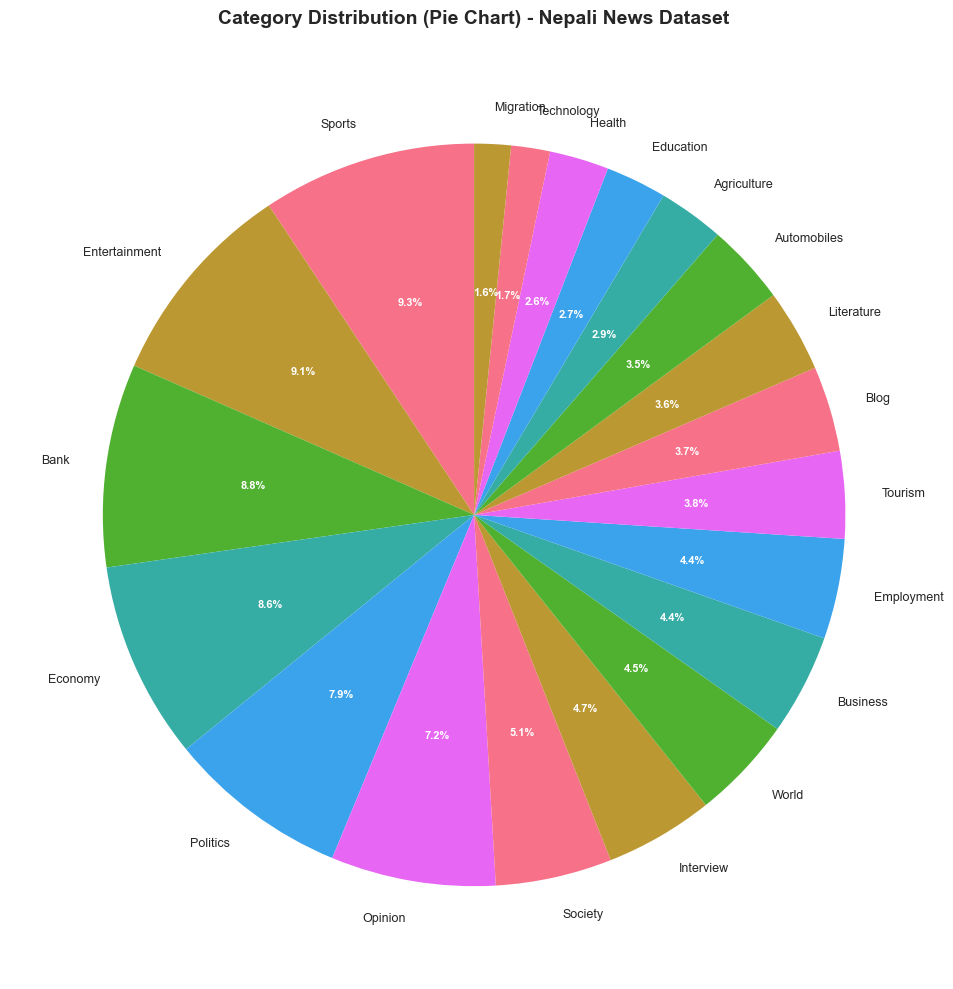

✓ Chart saved to: results/visualizations/category_distribution_pie.png


In [10]:
# Pie chart - Category distribution
fig, ax = plt.subplots(figsize=(14, 10))
category_counts_sorted = df['category'].value_counts()

# Create pie chart
wedges, texts, autotexts = ax.pie(
    category_counts_sorted.values,
    labels=category_counts_sorted.index,
    autopct='%1.1f%%',
    startangle=90,
    textprops={'fontsize': 9}
)

# Improve text readability
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(8)

ax.set_title('Category Distribution (Pie Chart) - Nepali News Dataset', 
             fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig(project_root / 'results' / 'visualizations' / 'category_distribution_pie.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Chart saved to: results/visualizations/category_distribution_pie.png")


## 3. Analyze Text Length Statistics


In [11]:
# Calculate text length statistics
df['text_length'] = df['text'].str.len()
df['word_count'] = df['text'].str.split().str.len()

print("Text Length Statistics:")
print("=" * 60)
print(f"Character count - Mean: {df['text_length'].mean():.0f}, Median: {df['text_length'].median():.0f}")
print(f"Character count - Min: {df['text_length'].min()}, Max: {df['text_length'].max()}")
print(f"Character count - Std: {df['text_length'].std():.0f}")
print()
print(f"Word count - Mean: {df['word_count'].mean():.0f}, Median: {df['word_count'].median():.0f}")
print(f"Word count - Min: {df['word_count'].min()}, Max: {df['word_count'].max()}")
print(f"Word count - Std: {df['word_count'].std():.0f}")


Text Length Statistics:
Character count - Mean: 1968, Median: 876
Character count - Min: 2.0, Max: 44323.0
Character count - Std: 3020

Word count - Mean: 295, Median: 136
Word count - Min: 1.0, Max: 3826.0
Word count - Std: 424


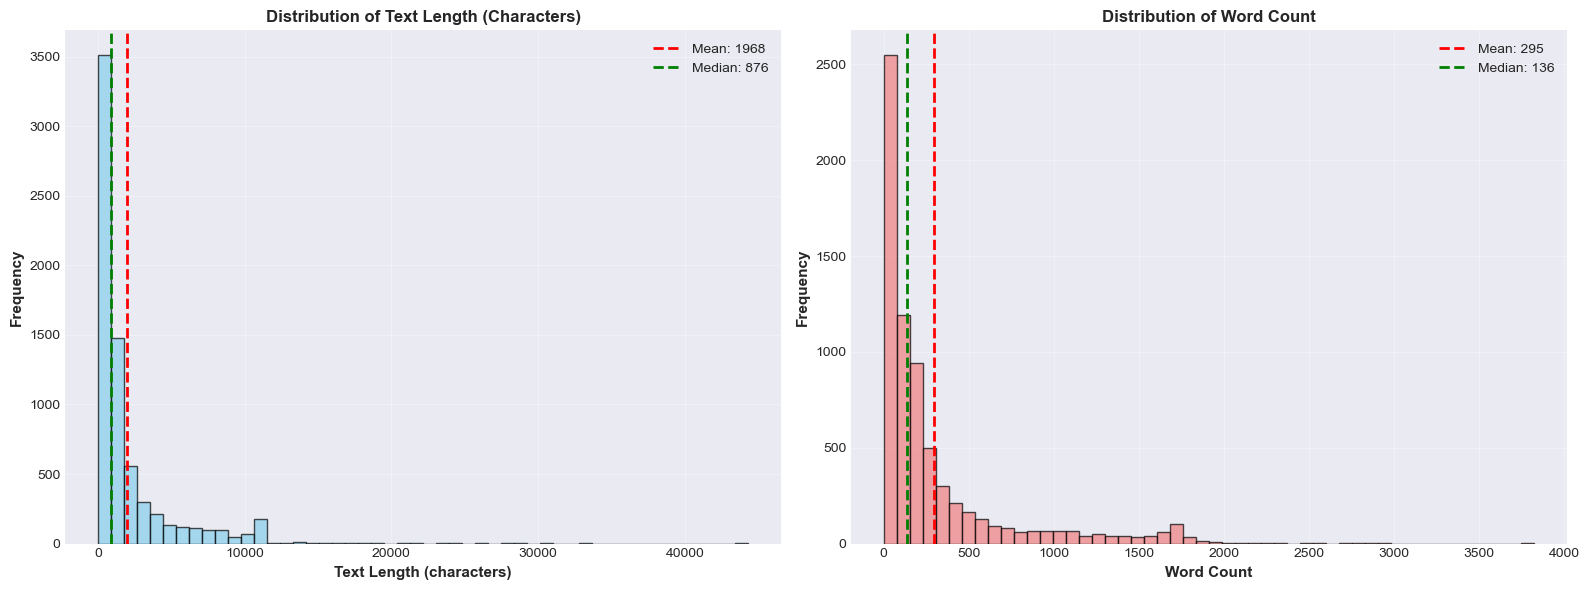

✓ Chart saved to: results/visualizations/text_length_distribution.png


In [12]:
# Text length distribution histogram
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Character count distribution
axes[0].hist(df['text_length'], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
axes[0].axvline(df['text_length'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df["text_length"].mean():.0f}')
axes[0].axvline(df['text_length'].median(), color='green', linestyle='--', linewidth=2, label=f'Median: {df["text_length"].median():.0f}')
axes[0].set_xlabel('Text Length (characters)', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Frequency', fontsize=11, fontweight='bold')
axes[0].set_title('Distribution of Text Length (Characters)', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Word count distribution
axes[1].hist(df['word_count'], bins=50, color='lightcoral', edgecolor='black', alpha=0.7)
axes[1].axvline(df['word_count'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df["word_count"].mean():.0f}')
axes[1].axvline(df['word_count'].median(), color='green', linestyle='--', linewidth=2, label=f'Median: {df["word_count"].median():.0f}')
axes[1].set_xlabel('Word Count', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Frequency', fontsize=11, fontweight='bold')
axes[1].set_title('Distribution of Word Count', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(project_root / 'results' / 'visualizations' / 'text_length_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Chart saved to: results/visualizations/text_length_distribution.png")


C:\Users\srish\AppData\Local\Temp\ipykernel_38820\2523702951.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box_plot = ax.boxplot([df_sorted[df_sorted['category'] == cat]['text_length'].values


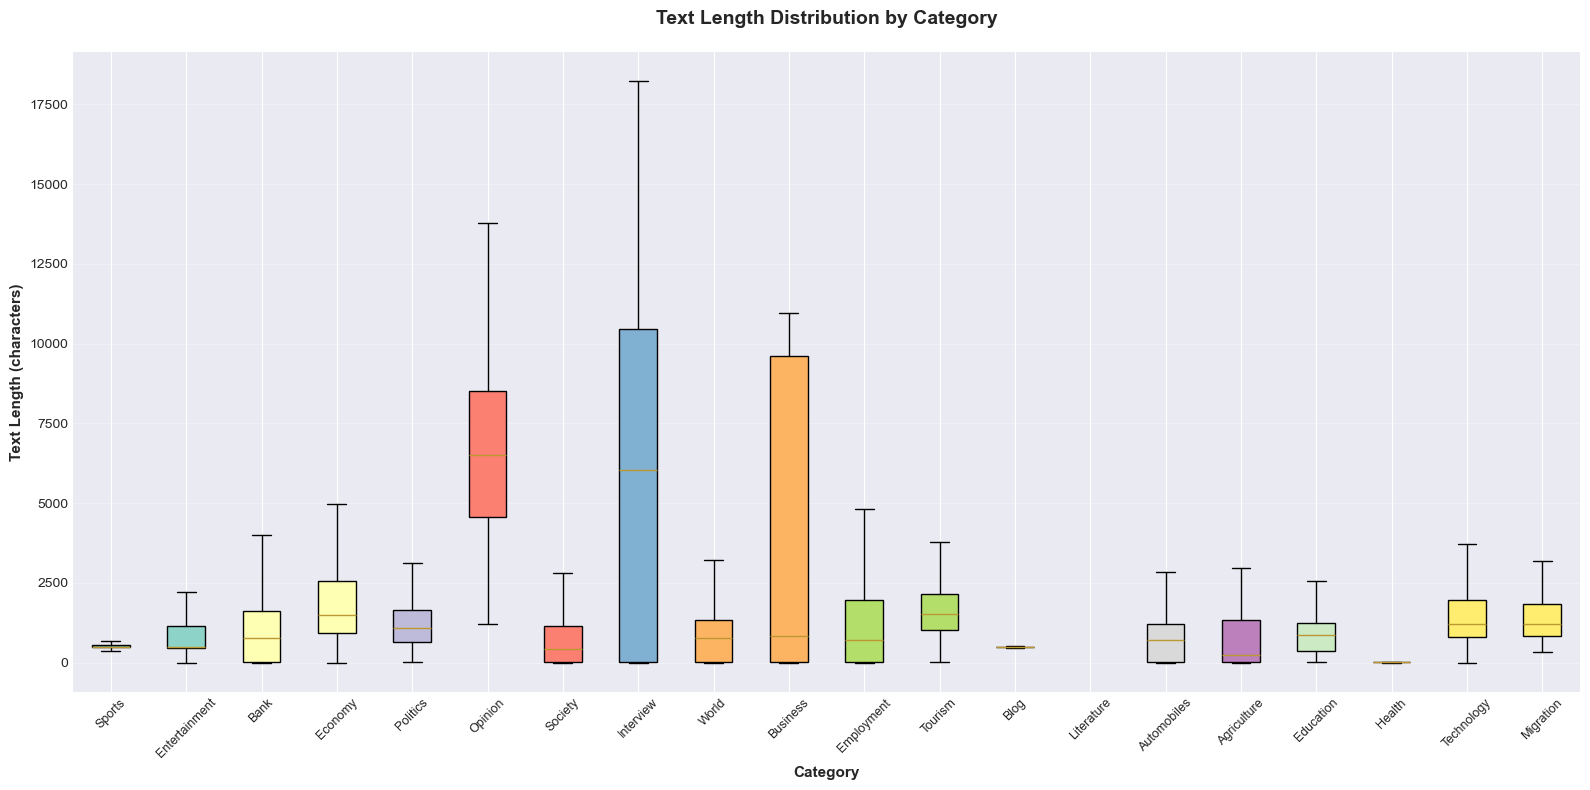

✓ Chart saved to: results/visualizations/text_length_by_category.png


In [13]:
# Box plot - Text length by category
fig, ax = plt.subplots(figsize=(16, 8))

# Prepare data
category_order = df['category'].value_counts().index
df_sorted = df.copy()
df_sorted['category'] = pd.Categorical(df_sorted['category'], categories=category_order, ordered=True)

# Create box plot
box_plot = ax.boxplot([df_sorted[df_sorted['category'] == cat]['text_length'].values 
                        for cat in category_order],
                       labels=category_order,
                       patch_artist=True,
                       showfliers=False)

# Color the boxes
colors = plt.cm.Set3(np.linspace(0, 1, len(category_order)))
for patch, color in zip(box_plot['boxes'], colors):
    patch.set_facecolor(color)

ax.set_xlabel('Category', fontsize=11, fontweight='bold')
ax.set_ylabel('Text Length (characters)', fontsize=11, fontweight='bold')
ax.set_title('Text Length Distribution by Category', fontsize=14, fontweight='bold', pad=20)
ax.tick_params(axis='x', rotation=45, labelsize=9)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(project_root / 'results' / 'visualizations' / 'text_length_by_category.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Chart saved to: results/visualizations/text_length_by_category.png")


In [14]:
# Text length statistics by category
text_stats_by_category = df.groupby('category')['text_length'].agg([
    'count', 'mean', 'median', 'std', 'min', 'max'
]).round(0).sort_values('count', ascending=False)

print("Text Length Statistics by Category:")
print("=" * 80)
print(text_stats_by_category.to_string())


Text Length Statistics by Category:
               count    mean  median     std     min      max
category                                                     
Sports           650   652.0   498.0   566.0    94.0   8213.0
Entertainment    634  1260.0   504.0  1996.0     5.0  11635.0
Bank             617  1140.0   767.0  1433.0     3.0  10809.0
Economy          600  1854.0  1482.0  1595.0     3.0  14168.0
Politics         550  1247.0  1096.0   787.0    11.0   5989.0
Opinion          500  7131.0  6506.0  4326.0  1209.0  44323.0
Society          353   884.0   416.0  1327.0     3.0   7738.0
Interview        330  5591.0  6038.0  4847.0     5.0  28449.0
World            313   894.0   760.0   969.0     3.0   7201.0
Business         306  4284.0   838.0  4956.0     3.0  28449.0
Employment       304  1452.0   708.0  2147.0     3.0  17717.0
Tourism          265  1714.0  1512.0  1049.0    13.0   7336.0
Blog             259  1006.0   493.0  1370.0   205.0   8572.0
Literature       248  2280.0   555

## 4. Class Imbalance Analysis


In [15]:
# Class imbalance analysis
category_counts = df['category'].value_counts()
min_count = category_counts.min()
max_count = category_counts.max()
avg_count = category_counts.mean()
imbalance_ratio = max_count / min_count

print("Class Imbalance Analysis:")
print("=" * 60)
print(f"Minimum samples per category: {min_count}")
print(f"Maximum samples per category: {max_count}")
print(f"Average samples per category: {avg_count:.1f}")
print(f"Imbalance ratio (max/min): {imbalance_ratio:.2f}x")
print()
print("Categories with low samples (< 200):")
low_sample_cats = category_counts[category_counts < 200]
for cat, count in low_sample_cats.items():
    print(f"  - {cat}: {count} samples")
print()
print("Categories with high samples (> 500):")
high_sample_cats = category_counts[category_counts > 500]
for cat, count in high_sample_cats.items():
    print(f"  - {cat}: {count} samples")


Class Imbalance Analysis:
Minimum samples per category: 111
Maximum samples per category: 650
Average samples per category: 348.6
Imbalance ratio (max/min): 5.86x

Categories with low samples (< 200):
  - Education: 185 samples
  - Health: 180 samples
  - Technology: 118 samples
  - Migration: 111 samples

Categories with high samples (> 500):
  - Sports: 650 samples
  - Entertainment: 634 samples
  - Bank: 617 samples
  - Economy: 600 samples
  - Politics: 550 samples


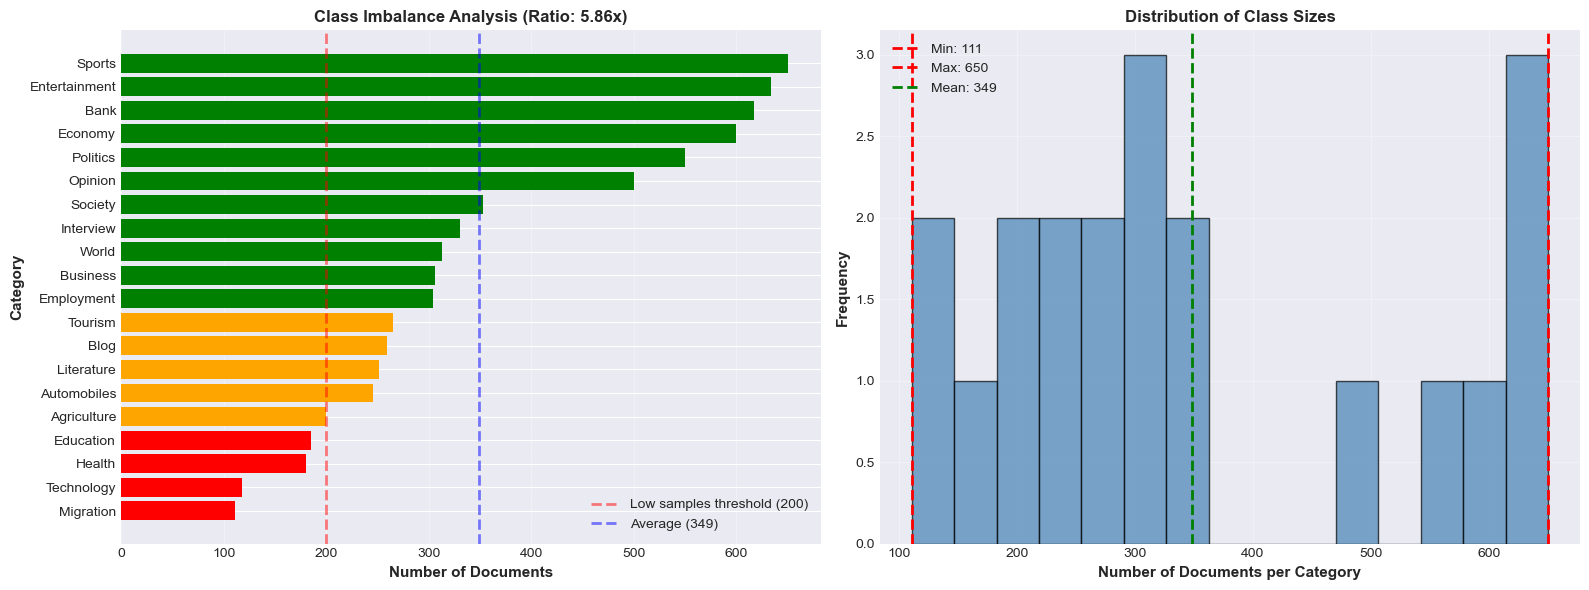

✓ Chart saved to: results/visualizations/class_imbalance_analysis.png


In [16]:
# Visualize class imbalance
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart showing imbalance
category_counts_sorted = category_counts.sort_values(ascending=True)
colors_imbalance = ['red' if count < 200 else 'orange' if count < 300 else 'green' 
                     for count in category_counts_sorted.values]

axes[0].barh(range(len(category_counts_sorted)), category_counts_sorted.values, color=colors_imbalance)
axes[0].axvline(200, color='red', linestyle='--', linewidth=2, alpha=0.5, label='Low samples threshold (200)')
axes[0].axvline(avg_count, color='blue', linestyle='--', linewidth=2, alpha=0.5, label=f'Average ({avg_count:.0f})')
axes[0].set_yticks(range(len(category_counts_sorted)))
axes[0].set_yticklabels(category_counts_sorted.index)
axes[0].set_xlabel('Number of Documents', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Category', fontsize=11, fontweight='bold')
axes[0].set_title(f'Class Imbalance Analysis (Ratio: {imbalance_ratio:.2f}x)', 
                  fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(axis='x', alpha=0.3)

# Distribution of class sizes
axes[1].hist(category_counts.values, bins=15, color='steelblue', edgecolor='black', alpha=0.7)
axes[1].axvline(min_count, color='red', linestyle='--', linewidth=2, label=f'Min: {min_count}')
axes[1].axvline(max_count, color='red', linestyle='--', linewidth=2, label=f'Max: {max_count}')
axes[1].axvline(avg_count, color='green', linestyle='--', linewidth=2, label=f'Mean: {avg_count:.0f}')
axes[1].set_xlabel('Number of Documents per Category', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Frequency', fontsize=11, fontweight='bold')
axes[1].set_title('Distribution of Class Sizes', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(project_root / 'results' / 'visualizations' / 'class_imbalance_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Chart saved to: results/visualizations/class_imbalance_analysis.png")


In [17]:
# Sample texts from different categories
print("Sample Texts from Different Categories:")
print("=" * 80)

sample_categories = ['Sports', 'Migration', 'Technology', 'Politics', 'Entertainment']
for category in sample_categories:
    sample_text = df[df['category'] == category]['text'].iloc[0]
    print(f"\n[{category}] (Length: {len(sample_text)} chars, {len(sample_text.split())} words)")
    print("-" * 80)
    print(sample_text[:300] + "..." if len(sample_text) > 300 else sample_text)
    print()


Sample Texts from Different Categories:

[Sports] (Length: 212 chars, 33 words)
--------------------------------------------------------------------------------
﻿विश्वकप टिकटको मूल्य

यसपटक विश्वकप फुटबल प्रत्यक्ष हेर्न चाहनेहरू धेरै नै देखिए । फिफाले आफ्नो वेबसाइटमार्फत रसिया विश्वकपको टिकटलाई अनलाइन बुकिङमा राख्न खोज्दा नै १५ लाख व्यक्तिले टिकटका लागि आवेदन दिएका थिए ।


[Migration] (Length: 3181 chars, 492 words)
--------------------------------------------------------------------------------
﻿कार्तिक २७, २०७४-विगत एक वर्षयता मलेसियाली मुद्रा ‘रिंगिट’ को भाउ सुध्रन सकेको छैन । रिंगिटमा आएको गिरावटका कारण यहाँ कार्यरत नेपालीहरु मर्कामा परेका छन् ।
मलेसियामा ५ लाखभन्दा बढी नेपाली कार्यरत छन् । तीमध्ये वैध रुपमा ३ लाख ८५ हजार ३ सय २० जना वैध रुपमा कार्यरत छन् । स्वदेशमा बढ्दो महंगी र यहाँ व...


[Technology] (Length: 1205 chars, 201 words)
--------------------------------------------------------------------------------
﻿फेसबुकले आफ्ना प्रयोगकर्ताको गेम खेल्ने आदतको बारेमा नयाँ तथ्यांक 

## 5. Summary Statistics


In [18]:
# Generate comprehensive summary
print("=" * 80)
print("DATASET SUMMARY")
print("=" * 80)
print(f"\nTotal Documents: {len(df):,}")
print(f"Number of Categories: {len(label_to_id)}")
print(f"Total Characters: {df['text_length'].sum():,}")
print(f"Total Words: {df['word_count'].sum():,}")
print(f"\nText Length Statistics:")
print(f"  - Mean: {df['text_length'].mean():.0f} characters")
print(f"  - Median: {df['text_length'].median():.0f} characters")
print(f"  - Std Dev: {df['text_length'].std():.0f} characters")
print(f"  - Range: {df['text_length'].min():,} - {df['text_length'].max():,} characters")
print(f"\nWord Count Statistics:")
print(f"  - Mean: {df['word_count'].mean():.0f} words")
print(f"  - Median: {df['word_count'].median():.0f} words")
print(f"  - Std Dev: {df['word_count'].std():.0f} words")
print(f"  - Range: {df['word_count'].min()} - {df['word_count'].max()} words")
print(f"\nClass Imbalance:")
print(f"  - Imbalance Ratio: {imbalance_ratio:.2f}x")
print(f"  - Min samples: {min_count}")
print(f"  - Max samples: {max_count}")
print(f"  - Average samples: {avg_count:.1f}")
print(f"\nCategories with < 200 samples: {len(low_sample_cats)}")
print(f"Categories with > 500 samples: {len(high_sample_cats)}")
print("\n" + "=" * 80)


DATASET SUMMARY

Total Documents: 6,972
Number of Categories: 20
Total Characters: 13,712,110.0
Total Words: 2,059,095.0

Text Length Statistics:
  - Mean: 1968 characters
  - Median: 876 characters
  - Std Dev: 3020 characters
  - Range: 2.0 - 44,323.0 characters

Word Count Statistics:
  - Mean: 295 words
  - Median: 136 words
  - Std Dev: 424 words
  - Range: 1.0 - 3826.0 words

Class Imbalance:
  - Imbalance Ratio: 5.86x
  - Min samples: 111
  - Max samples: 650
  - Average samples: 348.6

Categories with < 200 samples: 4
Categories with > 500 samples: 5



## 6. Export Summary for Report

The following visualizations have been generated and saved:
1. `category_distribution.png` - Bar chart of category distribution
2. `category_distribution_pie.png` - Pie chart of category distribution
3. `text_length_distribution.png` - Histograms of text length and word count
4. `text_length_by_category.png` - Box plots of text length by category
5. `class_imbalance_analysis.png` - Class imbalance visualization

All visualizations are saved in `results/visualizations/` directory.


In [19]:
# Create summary dictionary for export
summary = {
    'total_documents': int(len(df)),
    'num_categories': int(len(label_to_id)),
    'text_length_stats': {
        'mean': float(df['text_length'].mean()),
        'median': float(df['text_length'].median()),
        'std': float(df['text_length'].std()),
        'min': int(df['text_length'].min()),
        'max': int(df['text_length'].max())
    },
    'word_count_stats': {
        'mean': float(df['word_count'].mean()),
        'median': float(df['word_count'].median()),
        'std': float(df['word_count'].std()),
        'min': int(df['word_count'].min()),
        'max': int(df['word_count'].max())
    },
    'class_imbalance': {
        'imbalance_ratio': float(imbalance_ratio),
        'min_count': int(min_count),
        'max_count': int(max_count),
        'avg_count': float(avg_count)
    },
    'category_distribution': category_counts.to_dict()
}

# Save summary to JSON
summary_path = project_root / 'results' / 'metrics' / 'eda_summary.json'

with open(summary_path, 'w', encoding='utf-8') as f:
    json.dump(summary, f, indent=2, ensure_ascii=False)

print(f"✓ Summary saved to: {summary_path}")
print("\nEDA Complete! All visualizations and summaries have been generated.")


✓ Summary saved to: d:\MSc Islington\NEural Networks and Deep Learning\Project\nepali_news_classification\results\metrics\eda_summary.json

EDA Complete! All visualizations and summaries have been generated.
